Make a binary classification dataset with Scikit-Learn's make_moons() function.

    For consistency, the dataset should have 1000 samples and a random_state=42.
    Turn the data into PyTorch tensors. Split the data into training and test sets using train_test_split with 80% training and 20% testing.


In [3]:
import sklearn
from sklearn.datasets import make_moons

# Make 1000 smaples
n_samples = 1000
X, y = make_moons(n_samples=n_samples, noise=0.2, random_state=42)



In [4]:
len(X), len(y)

(1000, 1000)

In [5]:
print(f" First 5 samples of X:\n{X[:5]} ")
print(f" First 5 samples of y:\n{y[:5]} ")


 First 5 samples of X:
[[-0.11166654  0.52022374]
 [ 1.14264982 -0.34257734]
 [ 0.79555796 -0.01144231]
 [ 0.11182668 -0.55193153]
 [-0.81646618  0.54399604]] 
 First 5 samples of y:
[1 1 1 1 0] 


In [6]:
# Make the dataFrame of circles data
import pandas as pd
make_moons = pd.DataFrame({"X1": X[:, 0],
                           "X2": X[:, 1],
                           "label": y})

make_moons.head()

,X1,X2,label
0,-0.111667,0.520224,1
1,1.142650,-0.342577,1
2,0.795558,-0.011442,1
3,0.111827,-0.551932,1
4,-0.816466,0.543996,0


In [7]:
make_moons.label.value_counts()

,count
label,
1,500
0,500


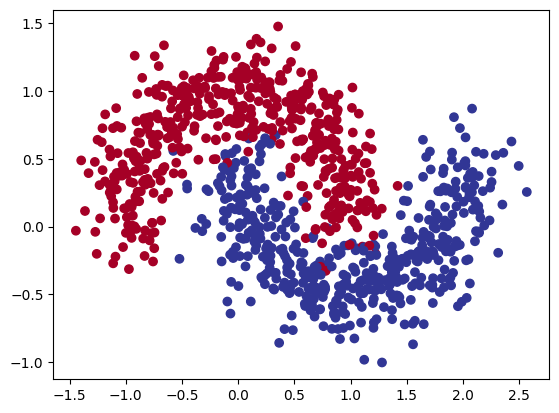

In [8]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu)

In [9]:
# Check the shapes of our feaures and labels
X.shape, y.shape

((1000, 2), (1000,))

In [ ]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X: {X_sample} and the same for the y: {y_sample}")
print(f" Shapes for one samples of X: {X_sample.shape} and the same for y: {y_sample}")

In [10]:
# Turn the data into tensors
# Otherwise this causes issues with multiplcations later on
import torch
import numpy as np

def ensure_tensor(data, dtype=torch.float):
    if isinstance(data, np.ndarray):
        return torch.from_numpy(data).type(dtype)
    elif isinstance(data, torch.Tensor):
        return data.type(dtype)
    else:
        raise TypeError(f"Unsupported data type: {type(data)}")

X = ensure_tensor(X)
y = ensure_tensor(y)

print(X[:5], y[:5])


tensor([[-0.1117,  0.5202],
        [ 1.1426, -0.3426],
        [ 0.7956, -0.0114],
        [ 0.1118, -0.5519],
        [-0.8165,  0.5440]]) tensor([1., 1., 1., 1., 0.])


In [11]:
# Splitting the data for train and test splits
from sklearn.model_selection import train_test_split

X_train , X_test, y_train , y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [54]:
import torch
from torch import nn

# Make the device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

#Building a model


In [55]:
# Construct a model that subclasses the nn.Module
class MakeMoons(nn.Module):
    def __init__(self, in_features, out_features, hidden_units):
        super().__init__()
        self.layer_1 = nn.Linear(in_features, hidden_units)
        self.layer_2 = nn.Linear(hidden_units, hidden_units)
        self.layer_3 = nn.Linear(hidden_units, out_features)
        self.relu = nn.ReLU()

    # Define the forward pass properly
    def forward(self, x):
        x = self.relu(self.layer_1(x))
        x = self.relu(self.layer_2(x))
        x = self.layer_3(x)
        return x

# Instantiate model
model_0 = MakeMoons(in_features=2, out_features=1, hidden_units=10).to(device)


# Setting up the binary classifier compatible loss function and optimizer to use when training the model built  in

In [56]:
loss_fn = nn.BCEWithLogitsLoss()  # Sigmoid build in
# losCELoss()   # requires  the sigmoid layer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


Create a training and testing loop to fit the model you created in 2 to the data you created in 1.

In [57]:
# what's coming out of the model

# Logits
print("Logits")

print(model_0(X_train.to(device) [:10]).squeeze())

# Prediction probabilities

print("Pred probs")
print(torch.sigmoid(model_0(X_train.to(device) [:10]).squeeze()))

# Predictions probabilties
print("Preds Labels")
print(torch.round(torch.sigmoid(model_0(X_train.to(device) [:10]).squeeze())))


Logits
tensor([0.0027, 0.0080, 0.0116, 0.0191, 0.0273, 0.0208, 0.0236, 0.0245, 0.0318,
        0.0068], device='cuda:0', grad_fn=<SqueezeBackward0>)
Pred probs
tensor([0.5007, 0.5020, 0.5029, 0.5048, 0.5068, 0.5052, 0.5059, 0.5061, 0.5080,
        0.5017], device='cuda:0', grad_fn=<SigmoidBackward0>)
Preds Labels
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], device='cuda:0',
       grad_fn=<RoundBackward0>)


In [34]:
# Let's calculate the accuracy
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn


MulticlassAccuracy()

In [47]:
print(X_train.shape, y_train.shape)


torch.Size([800, 2]) torch.Size([800])


In [58]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

# Check shapes
print(X_train.shape, X_test.shape)


torch.Size([800, 2]) torch.Size([200, 2])


In [53]:
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)

epochs=1000

# Send data to the device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Loop through the data
for epoch in range(epochs):
  ### Training
  model_0.train()

  # 1. Forward pass
  y_logits = model_0(X_train).squeeze()
  # print(y_logits[:5]) # model raw outputs are "logits"
  y_pred_probs = torch.sigmoid(y_logits)
  y_pred = torch.round(y_pred_probs)

  # 2. Calculaute the loss
  loss = loss_fn(y_logits, y_train) # loss = compare model raw outputs to desired model outputs
  acc = acc_fn(y_pred, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression)
  optimizer.step()

  ### Testing
  model_0.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    # 2. Caculate the loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_pred, y_test.int())

  # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")






RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x800 and 2x10)

# Make predictions with the trained model and plot them using the plot_decision_boundary() function created in the notebook

In [59]:
# Plot the model predicions

import numpy as np

def plot_decision_boundary(model, X, y):
  model.to("cpu")
  X, y = X.to("cpu"), y.to("cpu")

  # ource - https://madewithml.com/courses/foundations/neural-networks/
  # (with modifications)

  x_min, x_max = X[:, 0].min() - 0.1 , X[:, 0].max() + 0.1
  y_min, y_max = X[:, 1].min() - 0.1 , X[:, 1].max() + 0.1
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

  # Make  features
  X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel() , yy.ravel()))).float

  # Making predictions
  model.eval()
  with torch.inference_mode():
    y_logits = model(X_to_pred_on).flatten()

  # Test for multi-class or binary and adjust the logits to predictions labels
  if len(torch.unique(y)) > 2:
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # multiclass

  else:
    y_pred = torch.round(torch.sigmoid(y_logits))   # binary


  # Rshape the preds and plot
  y_pred = y_pred.reshape(xx.shape).detach().numpy()
  plt.countourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
  plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
  plt.xlim(xx.min() , xx.max())
  plt.ylim(yy.min(), yy.max())






In [61]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    # Ensure model is in evaluation mode
    model.eval()
    with torch.inference_mode():
        # Set up mesh grid over the feature space
        x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
        y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                             np.linspace(y_min, y_max, 100))

        # Prepare grid for prediction
        grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float().to(next(model.parameters()).device)
        preds = torch.sigmoid(model(grid))  # <-- make predictions
        preds = preds.reshape(xx.shape)

    # Plot the contour
    plt.contourf(xx, yy, preds.cpu(), cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0].cpu(), X[:, 1].cpu(), c=y.cpu(), cmap=plt.cm.RdYlBu)


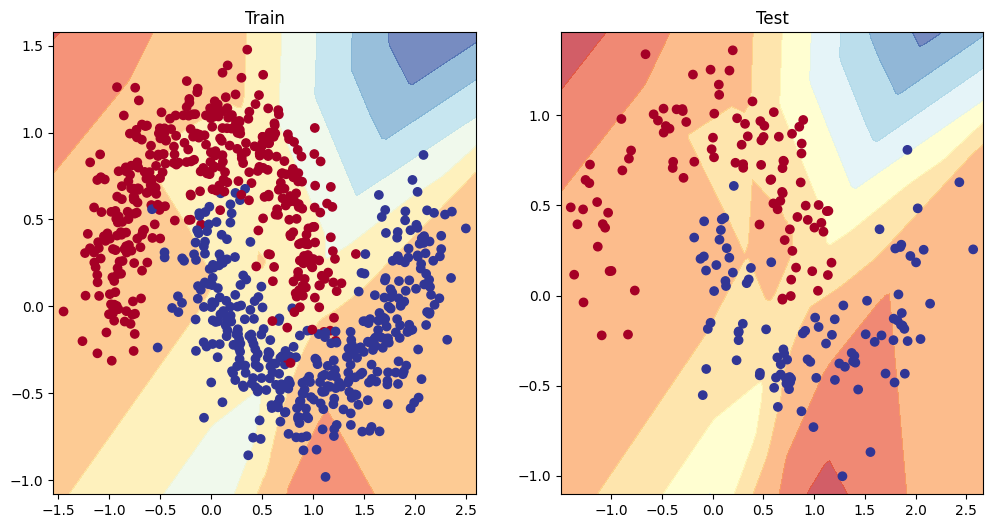

In [63]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


## Replicate the tanh (Hyperbolic tangent) activation function in pure Pytorch



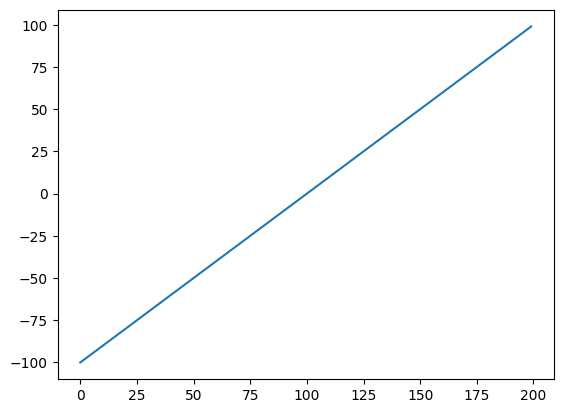

In [64]:
tensor_A = torch.arange(-100, 100, 1)
plt.plot(tensor_A)

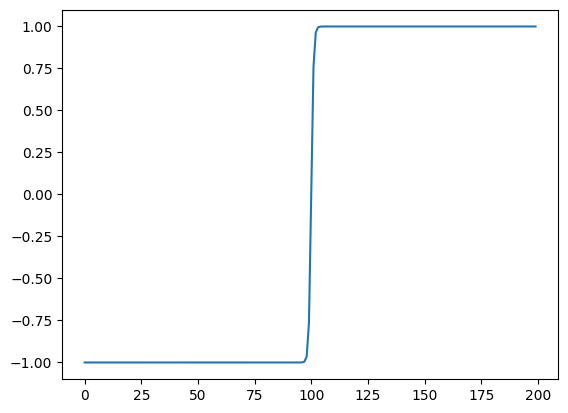

In [65]:
plt.plot(torch.tanh(tensor_A))

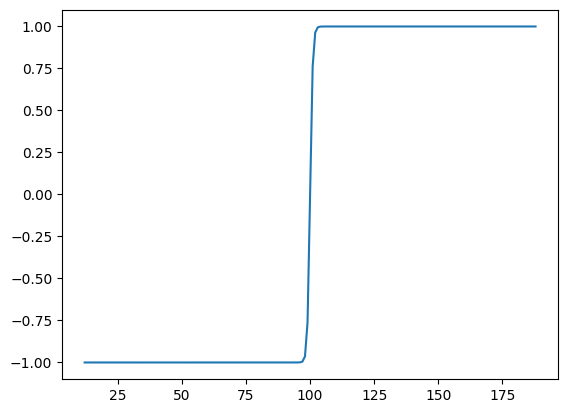

In [66]:
def tanh(x):
  return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(tanh(tensor_A))

# Creating a multi-class dataset using the spirals data creatiob from C231n


    * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
    * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
    * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
    *  Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like).
    * Plot the decision boundaries on the spirals dataset from your model predictions, the plot_decision_boundary() function should work for this dataset too.



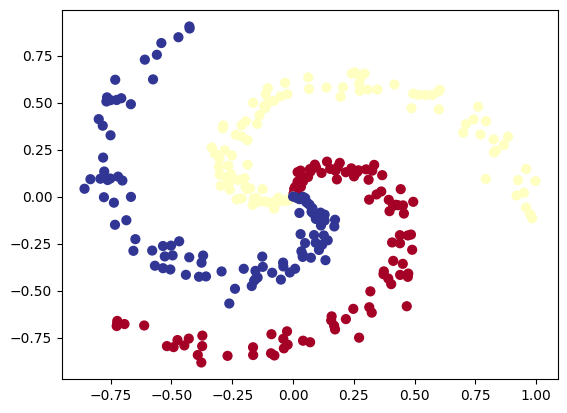

In [76]:
# Code for creating a spiral dataset from CS231n
import numpy as np
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

N = 100
D = 2
K = 3
X = np.zeros((N * K ,D))
y = np.zeros(N * K, dtype='uint8')
for j in range(K):
  ix = range(N*j, N*(j + 1))

  r = np.linspace(0.0, 1, N) # radius
  t = np.linspace(j * 4, (j + 1) * 4, N) + np.random.randn(N)*0.2 # Theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j

# Let visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)

plt.show()

In [77]:
#  Turn data into tensors
X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
len(X_train), len(X_test), len(y_train), len(y_test)

(240, 60, 240, 60)

In [79]:
!pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [83]:
# Preparing the deviced agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

class SpiralModel(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear1 = nn.Linear(in_features=2, out_features=10)
    self.linear2 = nn.Linear(in_features=10, out_features=10)
    self.linear3 = nn.Linear(in_features=10, out_features=3)
    self.relu = nn.ReLU()

  def  forward(self, x):
    return self.linear3(self.relu(self.linear2(self.relu(self.linear1(x)))))
model_1 = SpiralModel().to(device)
model_1

SpiralModel(
  (linear1): Linear(in_features=2, out_features=10, bias=True)
  (linear2): Linear(in_features=10, out_features=10, bias=True)
  (linear3): Linear(in_features=10, out_features=3, bias=True)
  (relu): ReLU()
)

In [84]:
# Setup data to be device agnostic
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
print(X_train.dtype, X_test.dtype, y_train.dtype, y_test.dtype)

# Print out untrained model outputs
print("Logits:")
print(model_1(X_train)[:10])

print("Pred probs:")
print(torch.softmax(model_1(X_train)[:10], dim=1))

print("Pred labels:")
print(torch.softmax(model_1(X_train)[:10], dim=1).argmax(dim=1))

torch.float32 torch.float32 torch.int64 torch.int64
Logits:
tensor([[ 0.0112, -0.1088,  0.1030],
        [ 0.0266, -0.1382,  0.1020],
        [-0.0277, -0.0701,  0.1016],
        [-0.0428, -0.0787,  0.0939],
        [-0.0592, -0.0476,  0.0876],
        [-0.0321, -0.0653,  0.0949],
        [-0.0313, -0.0622,  0.0959],
        [-0.0135, -0.1020,  0.1211],
        [ 0.0046, -0.1204,  0.0982],
        [-0.0430, -0.0788,  0.0942]], device='cuda:0',
       grad_fn=<SliceBackward0>)
Pred probs:
tensor([[0.3352, 0.2973, 0.3675],
        [0.3417, 0.2898, 0.3685],
        [0.3229, 0.3095, 0.3675],
        [0.3214, 0.3101, 0.3685],
        [0.3155, 0.3192, 0.3654],
        [0.3223, 0.3118, 0.3659],
        [0.3220, 0.3122, 0.3657],
        [0.3269, 0.2992, 0.3739],
        [0.3355, 0.2961, 0.3684],
        [0.3213, 0.3101, 0.3686]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Pred labels:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


In [86]:
# Set up the function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_1.parameters(),
                             lr=0.02)

In [87]:
# Build and training loop for the model
epochs = 1000

# Loop over the data
for epoch in range(epochs):
  model_1.train()

  y_logits = model_1(X_train)
  y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

  # Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_pred, y_train)

  # Optimizer zero grad
  optimizer.zero_grad()

  # 4 Loss backward
  loss.backward()

  # 5 Optimizer step step step
  optimizer.step

  # Testing
  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test)
    test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)

    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_pred, y_test)

    # Print out what's happening
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")



Epoch: 0 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 100 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 200 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 300 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 400 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 500 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 600 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 700 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 800 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37
Epoch: 900 | Loss: 1.09 Acc: 0.32 | Test loss: 1.08 Test acc: 0.37


In [92]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    # Ensure model is in evaluation mode
    model.eval()

    # Move tensors to CPU for plotting
    X = X.cpu()
    y = y.cpu()

    # Create a mesh grid over the feature space
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))

    # Convert meshgrid to tensor and send to model's device
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float).to(next(model.parameters()).device)

    # Get model predictions
    with torch.inference_mode():
        preds = torch.softmax(model(grid), dim=1)
        pred_labels = torch.argmax(preds, dim=1)

    # Move predictions to CPU for visualization
    pred_labels = pred_labels.cpu().numpy().reshape(xx.shape)

    # Plot contour
    plt.contourf(xx, yy, pred_labels, alpha=0.6, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, cmap=plt.cm.RdYlBu)


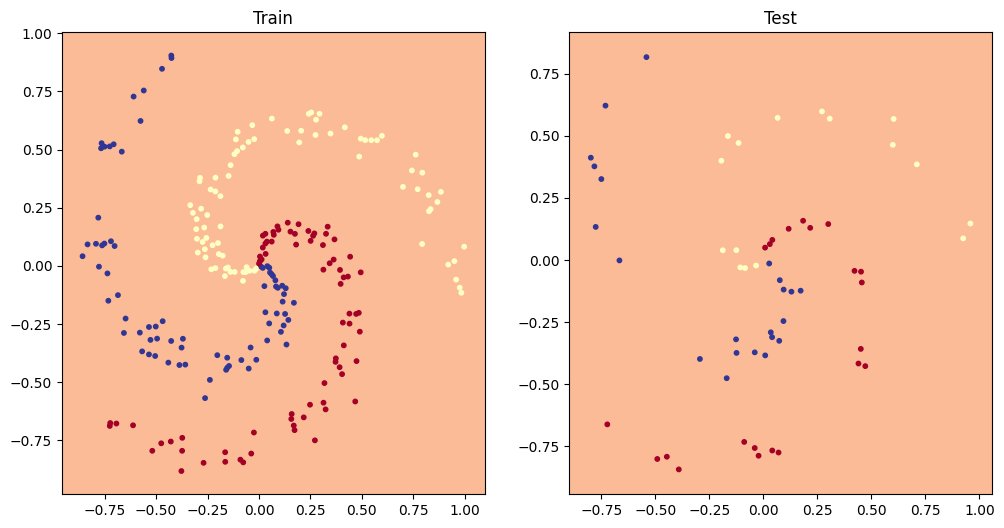

In [93]:
# Plotting decision boundaries for the training and test sets

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)